This notebook generates Fig 4A, S8B, S8C

In [1]:
from coding_model_fanofactor import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
############################
# glomerular response model#
############################

F_max = 1
N = 20 # N^2 ORNs
n = 4 # Hill coef = 4 for the 4 cooperative CNG binding sites

rng = np.random.default_rng(seed=42)
# receptor parameters
rho = 0.5 #1.0 #0.5 # antagonism parameter (correlation between sensitivity and activation efficiency; see eq (22))
total_bg = 16 # total num of background odors
b = total_bg + 2 # number of odors??
lnkappa = rng.standard_normal((b,N,N)) # log kappa is normal
lneta = rng.standard_normal((b,N,N)) # log eta is normal
lneta = rho*lnkappa + np.sqrt(1 - rho*rho)*lneta # set the correlation; rho = 0 is fully antagonistic, rho = 1 is not at all antogonistic
lnkappa = -4*lnkappa
kappa = np.exp(lnkappa)
n_samp = 10
n_cue_conc_levels = 10
cue_concs = np.logspace(-8, 8, n_cue_conc_levels) 
n_bg = 15
cue_conc = bg_conc = 1e-3

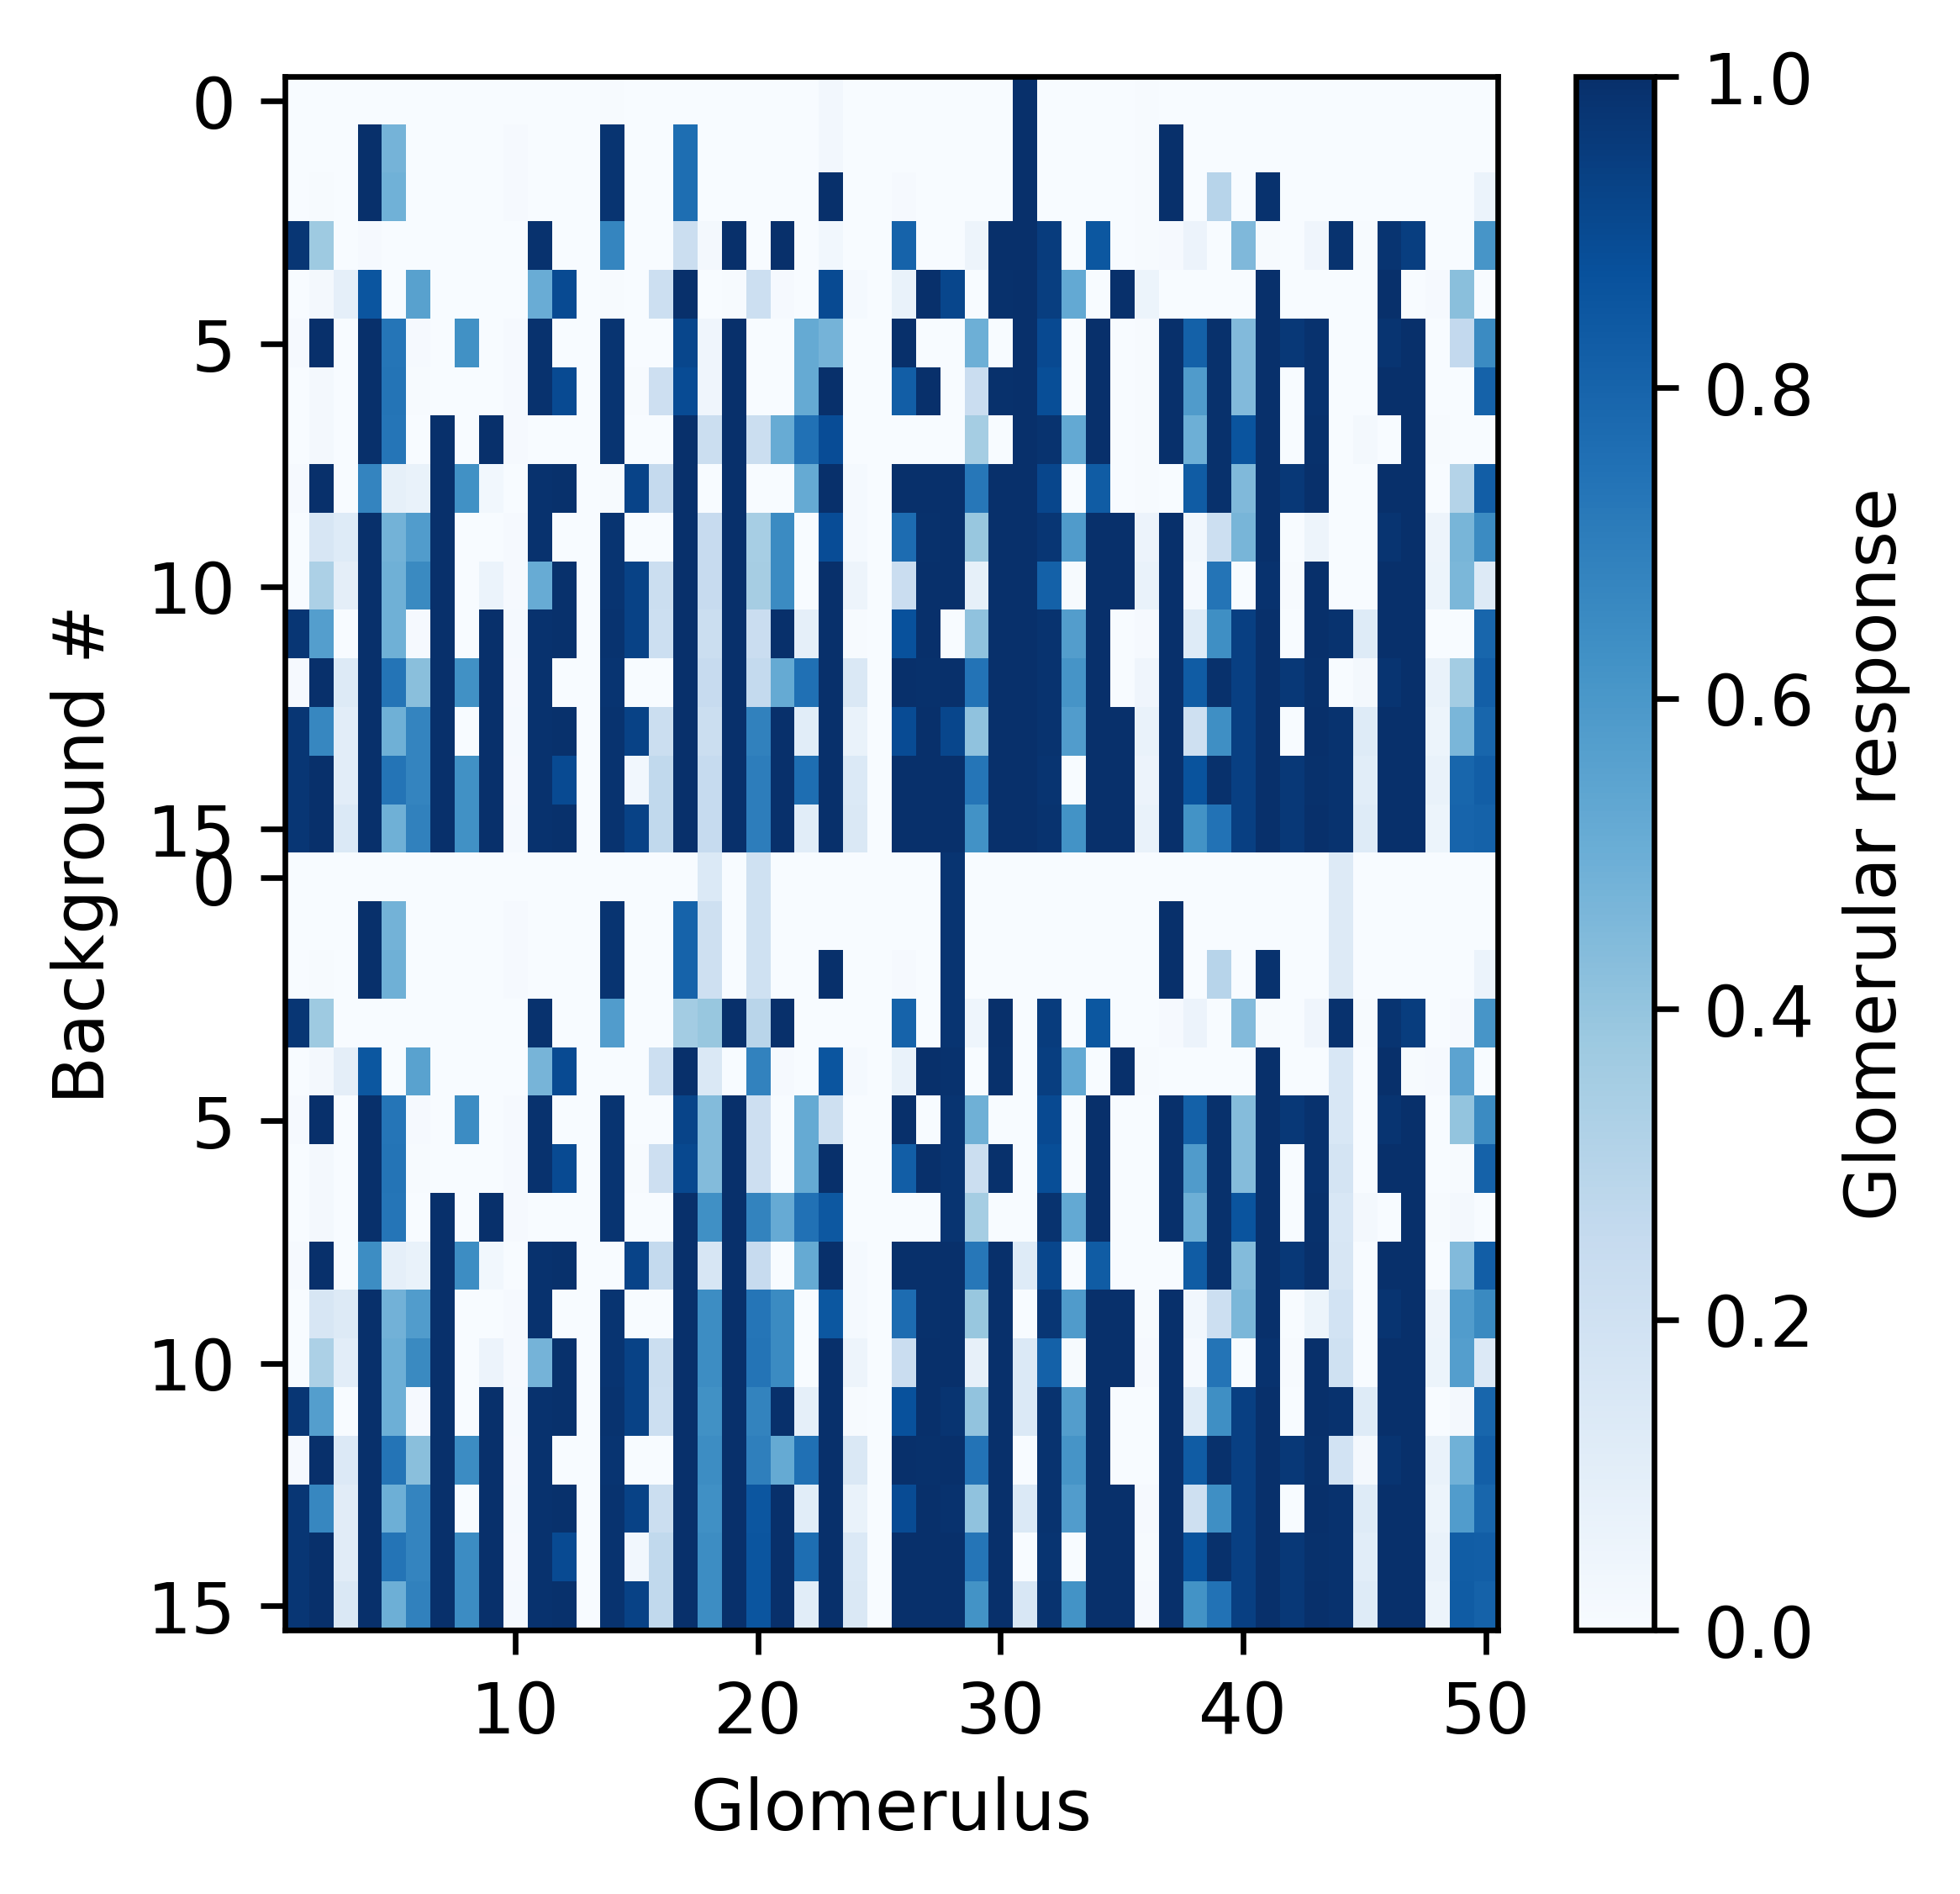

In [3]:
# model params (or reuse your existing ones if already defined)
model_params = init_model_parameters(total_bg=16, bg_conc=bg_conc, train_cue_conc=cue_conc, seed=42)
kappa = model_params["kappa"]
eta = model_params["eta"]
b = model_params["b"]
N = model_params["N"]
F_max = model_params["F_max"]
hill_n = model_params["n"]
inv_kappa = 1.0 / kappa

n_glom_shown = 50
max_n_bg = 16
cue1_responses = []
cue2_responses = []

for n_bg in range(max_n_bg):
    concs1, _ = generate_odor_vecs_vectorized(
        n_samp, cue_conc, bg_conc, cue=0, n_bg=n_bg, total_bg=model_params["total_bg"]
    )
    concs2 = concs1.copy()
    concs2[:, 0] = 0.0
    concs2[:, 1] = cue_conc

    conc_tensor1 = tensorize_concs(concs1, n_samp, b, N)
    conc_tensor2 = tensorize_concs(concs2, n_samp, b, N)

    resp1 = compute_activity_vec(
        conc_tensor1, kappa, eta, F_max, hill_n, sigma=0.0, inv_kappa=inv_kappa, fano_factor_one=False
    )
    resp2 = compute_activity_vec(
        conc_tensor2, kappa, eta, F_max, hill_n, sigma=0.0, inv_kappa=inv_kappa, fano_factor_one=False
    )

    # first sample only
    r1 = resp1[0].ravel()[:n_glom_shown]
    r2 = resp2[0].ravel()[:n_glom_shown]
    cue1_responses.append(r1)
    cue2_responses.append(r2)

example_responses = np.concatenate((np.vstack(cue1_responses), np.vstack(cue2_responses)))
plt.figure(figsize=(4, 4), dpi=600)
plt.imshow(example_responses, cmap="Blues", vmin=0, vmax=1, aspect=2.0)
plt.colorbar(label="Glomerular response")
plt.xlabel("Glomerulus")
plt.ylabel("Background #")
yticks = np.concatenate((np.arange(max_n_bg)[::5], np.arange(max_n_bg)[::5]))
plt.yticks(ticks=[0, 5, 10, 15, 16, 21, 26, 31], labels=yticks)
xticks = np.arange(10, 51, 10)
plt.xticks(xticks - 1, labels=xticks)
plt.savefig(f"../figures/manuscript/example_glomerular_responses_bgconc_{bg_conc}_cueconc_{cue_conc}.svg", dpi=600)


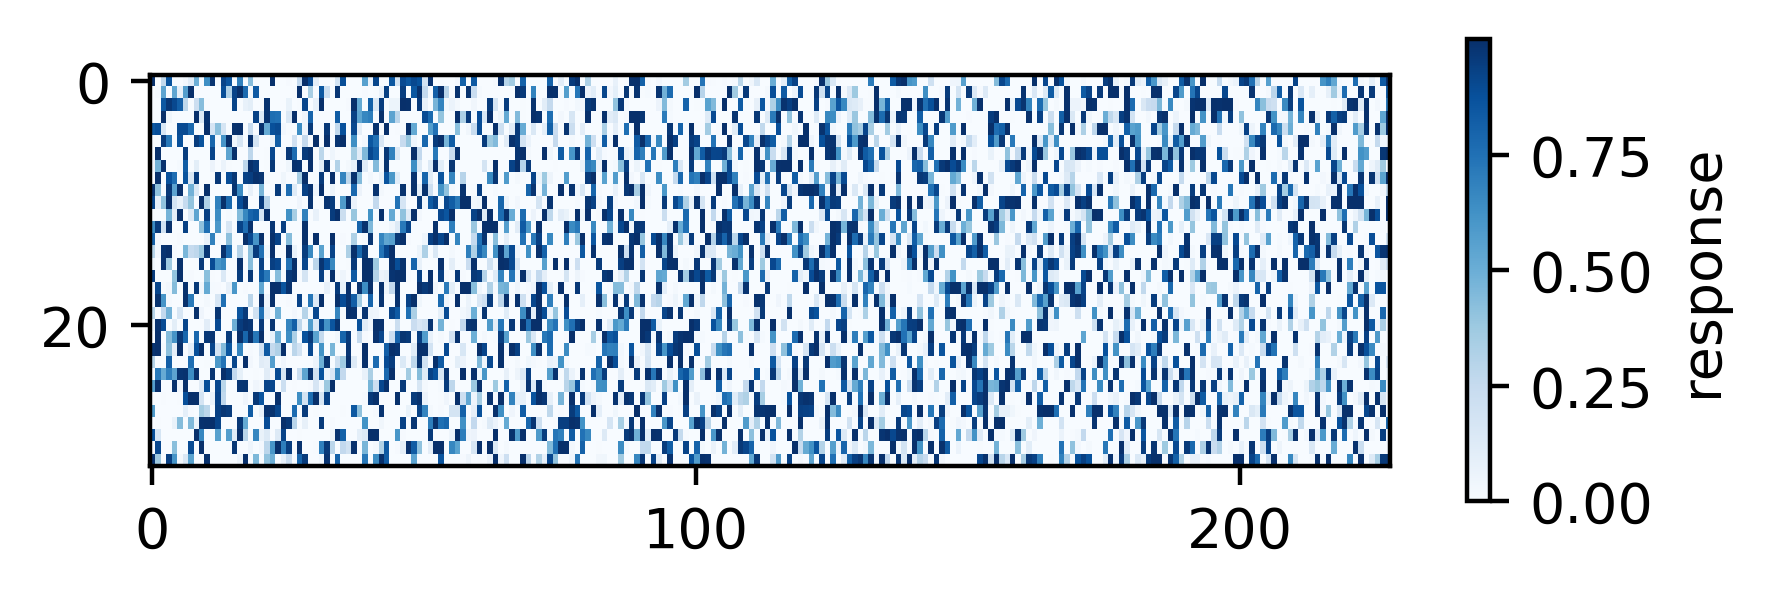

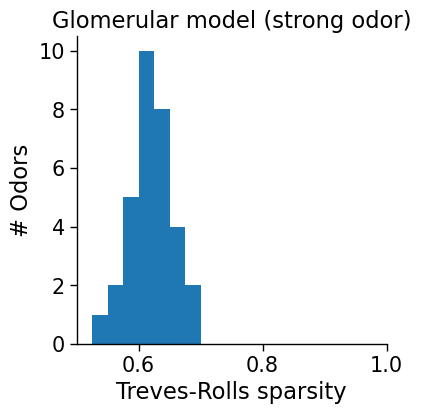

In [4]:
# compute population sparsity for 32 single odors
conc = 1e0 # 1e-3 # 1e-3 is weak, 1e0 is strong
n_glom_shown = 228
b = 32  # number of single odors/channels

concs = np.eye(b) * conc
conc_tensor = tensorize_concs(concs, n_samp=concs.shape[0], b=concs.shape[1], N=N)

rng = np.random.default_rng(42)
lnkappa = rng.standard_normal((b, N, N))
lneta = rng.standard_normal((b, N, N))
lneta = rho * lnkappa + np.sqrt(1 - rho * rho) * lneta
lnkappa = -4 * lnkappa
kappa = np.exp(lnkappa)
eta = np.exp(lneta)

inv_kappa = 1.0 / kappa
F_max = 1
hill_n = 4

r = compute_activity_vec(
    conc_tensor,
    kappa,
    eta,
    F_max=F_max,
    n=hill_n,
    sigma=0.0,
    inv_kappa=inv_kappa,
    fano_factor_one=False,
).reshape(concs.shape[0], -1)[:, :n_glom_shown]

fig, ax = plt.subplots(figsize=(5, 1.5), dpi=400)
cax = ax.imshow(r, cmap="Blues", aspect=2.25)
fig.colorbar(mappable=cax, label="response")

sns.set_context("paper", font_scale=1.7)
plt.figure(figsize=(4, 4))
plt.hist(population_sparsity(r.T), bins=np.arange(0.5, 1.025, 0.025))
plt.xlabel("Treves-Rolls sparsity")
plt.ylabel("# Odors")
plt.xlim(0.5, 1.0)
if conc == 1e-3:
    plt.title("Glomerular model (weak odor)")
elif conc == 1e0:
    plt.title("Glomerular model (strong odor)")

sns.despine()
plt.savefig(f"../figures/manuscript/glomerular_model_sparsity_conc{conc}.svg", dpi=600, bbox_inches="tight")
plt.savefig(f"../figures/manuscript/glomerular_model_sparsity_conc{conc}.png", dpi=600, bbox_inches="tight")
